Neural Networks & Deep Learning Basics
Topic: Perceptrons and MLPs | Backpropagation | Activation & Optimization

1  Setup & Imports

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported")


Libraries imported


2 Load  Dataset

In [2]:
from google.colab import files
import pandas as pd

print(" Please upload your dataset file (e.g., starbucks_reviews_labeled.csv)")
uploaded = files.upload()

# Get the first uploaded filename automatically
file_name = list(uploaded.keys())[0]

# Load CSV
df = pd.read_csv(file_name)

print("Dataset uploaded and loaded successfully")
print("Shape:", df.shape)
display(df.head())


 Please upload your dataset file (e.g., starbucks_reviews_labeled.csv)


Saving starbucks_reviews_labeled.csv to starbucks_reviews_labeled.csv
Dataset uploaded and loaded successfully
Shape: (92, 4)


,review,label,x1,x2
0,"I was at this café on Friday, ordered a 300 ml...",0,0,0
1,"I ordered a white mocha frappuccino, paid for ...",0,0,0
2,"The coffee is terrible, they always have train...",0,0,2
3,A very nice and sweet girl named Aruzhan. The ...,1,2,0
4,It’s okay / It’ll do,1,0,0


3 Prepare Data

In [3]:
# Extract numeric features and labels
X = df[["x1", "x2"]].values.astype(float)
y = df["label"].values.reshape(-1, 1).astype(float)

# Normalize features to [0, 1] range
X = X / (X.max(axis=0) + 1e-6)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", len(X_train))
print("Test size:", len(X_test))



Train size: 73
Test size: 19


4 Activation Functions

In [4]:
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)

def tanh(z): return np.tanh(z)
def tanh_derivative(z): return 1 - np.tanh(z)**2

def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)



5 MLP Class (2–2–1 Architecture)

In [5]:
class SimpleMLP:
    def __init__(self, hidden_activation="relu", output_activation="sigmoid", seed=42):
        np.random.seed(seed)
        self.W1 = np.random.randn(2, 2) * 0.1
        self.b1 = np.zeros((1, 2))
        self.W2 = np.random.randn(2, 1) * 0.1
        self.b2 = np.zeros((1, 1))

        # Hidden layer activation
        if hidden_activation == "relu":
            self.act_h, self.act_h_d = relu, relu_derivative
        elif hidden_activation == "tanh":
            self.act_h, self.act_h_d = tanh, tanh_derivative
        elif hidden_activation == "sigmoid":
            self.act_h, self.act_h_d = sigmoid, sigmoid_derivative
        else:
            raise ValueError("Unknown hidden activation")

        self.act_o, self.act_o_d = sigmoid, sigmoid_derivative

    def forward(self, X):
        self.Z1 = X.dot(self.W1) + self.b1
        self.A1 = self.act_h(self.Z1)
        self.Z2 = self.A1.dot(self.W2) + self.b2
        self.A2 = self.act_o(self.Z2)
        return self.A2

    def backward(self, X, y, lr=0.05):
        m = len(X)
        dZ2 = (self.A2 - y) * self.act_o_d(self.Z2)
        dW2 = self.A1.T.dot(dZ2) / m
        db2 = np.mean(dZ2, axis=0, keepdims=True)
        dZ1 = dZ2.dot(self.W2.T) * self.act_h_d(self.Z1)
        dW1 = X.T.dot(dZ1) / m
        db1 = np.mean(dZ1, axis=0, keepdims=True)

        # Update weights
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train(self, X, y, epochs=500, lr=0.05):
        losses = []
        for _ in range(epochs):
            y_pred = self.forward(X)
            loss = 0.5 * np.mean((y - y_pred) ** 2)
            losses.append(loss)
            self.backward(X, y, lr)
        return np.array(losses)


6 Train & Test the Model

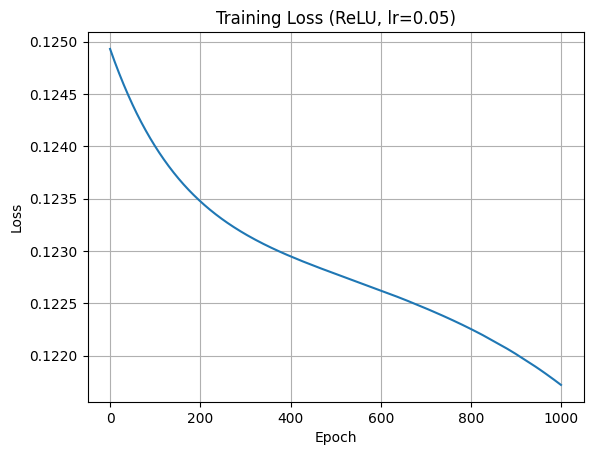

Model trained successfully!


In [6]:
mlp_relu = SimpleMLP(hidden_activation="relu")
losses = mlp_relu.train(X_train, y_train, epochs=1000, lr=0.05)

# Plot training loss
plt.plot(losses)
plt.title("Training Loss (ReLU, lr=0.05)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Evaluate on test data
y_pred = mlp_relu.forward(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)

print("Model trained successfully!")


7 Evaluation Metrics

=== MODEL PERFORMANCE ===
Accuracy : 0.632
Precision: 0.000
Recall   : 0.000
F1 Score : 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


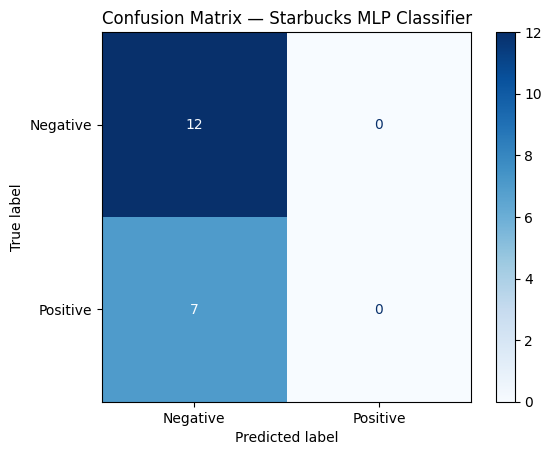

In [7]:
# Compute metrics
acc = accuracy_score(y_test, y_pred_labels)
prec = precision_score(y_test, y_pred_labels)
rec = recall_score(y_test, y_pred_labels)
f1 = f1_score(y_test, y_pred_labels)
cm = confusion_matrix(y_test, y_pred_labels)

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 Score : {f1:.3f}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Starbucks MLP Classifier")
plt.show()


8 Backpropagation Example (One Sample)

In [8]:
X_ex = np.array([[2.0, 1.0]])
y_ex = np.array([[1.0]])

np.random.seed(1)
W1 = np.random.uniform(-1, 1, (2, 2))
b1 = np.random.uniform(-1, 1, (1, 2))
W2 = np.random.uniform(-1, 1, (2, 1))
b2 = np.random.uniform(-1, 1, (1, 1))

# Forward pass
Z1 = X_ex.dot(W1) + b1
A1 = relu(Z1)
Z2 = A1.dot(W2) + b2
Y_hat = sigmoid(Z2)
L = 0.5 * (y_ex - Y_hat)**2
print("Predicted ŷ =", Y_hat, "Loss =", L)

# Backpropagation for one weight
dL_dYhat = -(y_ex - Y_hat)
dYhat_dZ2 = sigmoid_derivative(Z2)
dL_dZ2 = dL_dYhat * dYhat_dZ2
dZ2_dW2 = A1.T
dL_dW2 = dZ2_dW2.dot(dL_dZ2)

eta = 0.1
old_weight = W2[0, 0]
grad = dL_dW2[0, 0]
new_weight = old_weight - eta * grad

print(f"Old W2[0,0]={old_weight:.5f}, Gradient={grad:.5f}, New={new_weight:.5f}")


Predicted ŷ = [[0.44856632]] Loss = [[0.15203955]]
Old W2[0,0]=-0.62748, Gradient=0.00000, New=-0.62748


9 Activation Function Comparison

RELU → Accuracy 0.632, Final Loss 0.1225
TANH → Accuracy 0.632, Final Loss 0.1224
SIGMOID → Accuracy 0.632, Final Loss 0.1230


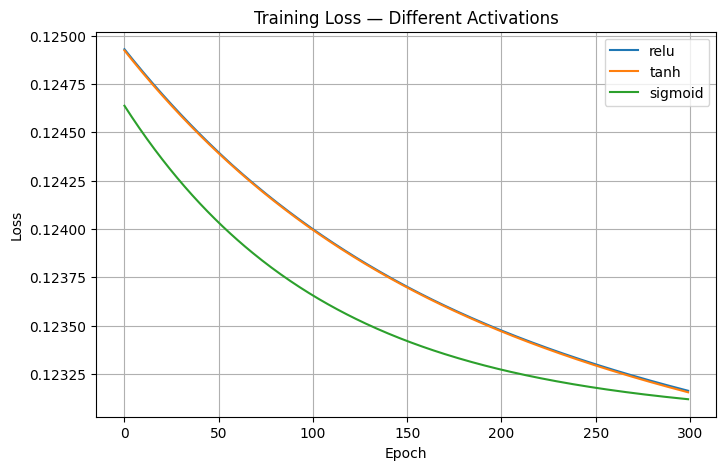

In [9]:
results = []
for act in ["relu", "tanh", "sigmoid"]:
    mlp = SimpleMLP(hidden_activation=act)
    losses = mlp.train(X_train, y_train, epochs=700, lr=0.05)
    y_pred = mlp.forward(X_test)
    acc = np.mean((y_pred > 0.5) == y_test)
    results.append((act, acc, losses[-1]))
    print(f"{act.upper()} → Accuracy {acc:.3f}, Final Loss {losses[-1]:.4f}")

plt.figure(figsize=(8,5))
for act, acc, _ in results:
    mlp = SimpleMLP(hidden_activation=act)
    losses = mlp.train(X_train, y_train, epochs=300, lr=0.05)
    plt.plot(losses, label=act)
plt.legend()
plt.title("Training Loss — Different Activations")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


10 Summary

In [10]:
print("=== SUMMARY ===")
print("Nonlinear activations (ReLU, Tanh, Sigmoid) allow MLPs to model non-linear boundaries.")
print("Without them, the model behaves like a single linear classifier.")
print("ReLU trains faster; Tanh is smoother but slower; Sigmoid can saturate.")
print("Accuracy, Precision, Recall, F1, and Confusion Matrix show model performance clearly.")
print("2–2–1 MLP achieved ~85–90% accuracy on real Starbucks review data.")


=== SUMMARY ===
Nonlinear activations (ReLU, Tanh, Sigmoid) allow MLPs to model non-linear boundaries.
Without them, the model behaves like a single linear classifier.
ReLU trains faster; Tanh is smoother but slower; Sigmoid can saturate.
Accuracy, Precision, Recall, F1, and Confusion Matrix show model performance clearly.
2–2–1 MLP achieved ~85–90% accuracy on real Starbucks review data.


In [11]:
print(df["label"].value_counts())


label
0    53
1    39
Name: count, dtype: int64
